<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day3_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

Shape : (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M



Types :
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symme

/tmp/ipykernel_4320/2019571562.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


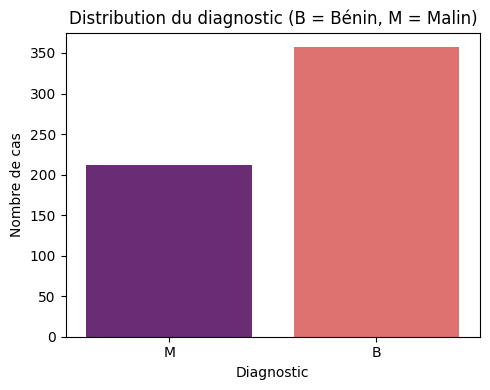

In [2]:



# ── EDA

# Chargement via sklearn (équivalent au CSV Kaggle)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
df['diagnosis'] = df['diagnosis'].map({0: 'M', 1: 'B'})  # 0=Malin, 1=Bénin

# Inspection initiale
print("Shape :", df.shape)
display(df.head())
print("\nTypes :")
print(df.dtypes)

# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df.isnull().sum().sort_values(ascending=False))
# Aucune valeur manquante dans ce dataset → pas de traitement nécessaire

# Suppression des colonnes inutiles
# Le dataset sklearn n'a pas de colonne 'id' — rien à supprimer
# Sur le CSV Kaggle, on ferait : df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Countplot de la colonne diagnosis avec palette magma
plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title("Distribution du diagnostic (B = Bénin, M = Malin)")
plt.xlabel("Diagnostic")
plt.ylabel("Nombre de cas")
plt.tight_layout()
plt.show()

In [3]:


# ── PREPROCESSING ────────────────────────────────────────────

# Comptage des valeurs uniques dans diagnosis
print("\nCounts de diagnosis :")
print(df['diagnosis'].value_counts())

# Mapping des valeurs catégorielles → numériques
# B (Bénin) → 1 | M (Malin) → 0
df['diagnosis'] = df['diagnosis'].map({'B': 1, 'M': 0})
print("\nAprès mapping :", df['diagnosis'].value_counts().to_dict())

# Séparation features / cible
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split train/test 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")

# Standardisation : obligatoire pour LR, KNN et SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Counts de diagnosis :
diagnosis
B    357
M    212
Name: count, dtype: int64

Après mapping : {1: 357, 0: 212}

Train : (455, 30) | Test : (114, 30)


In [4]:


# ── MODÈLES ─────────────────────────────────────────────────

results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_sc, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test_sc))
results['Logistic Regression'] = acc_lr
print(f"\nLogistic Regression Accuracy : {acc_lr:.4f}")

# 2. K Nearest Neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test_sc))
results['KNN'] = acc_knn
print(f"KNN Accuracy               : {acc_knn:.4f}")

# 3. Random Forest
# Random Forest n'a pas besoin de standardisation (basé sur des arbres)
# mais on l'applique quand même par cohérence du pipeline
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
results['Random Forest'] = acc_rf
print(f"Random Forest Accuracy     : {acc_rf:.4f}")

# 4. SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
acc_svm = accuracy_score(y_test, svm.predict(X_test_sc))
results['SVM'] = acc_svm
print(f"SVM Accuracy               : {acc_svm:.4f}")




Logistic Regression Accuracy : 0.9825
KNN Accuracy               : 0.9561
Random Forest Accuracy     : 0.9561
SVM Accuracy               : 0.9825



=== Tableau comparatif ===


,Accuracy
Logistic Regression,0.9825
SVM,0.9825
KNN,0.9561
Random Forest,0.9561



✅ Meilleur modèle : Logistic Regression (0.9825)


/tmp/ipykernel_4320/3739997795.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_model = df_results.idxmax()[0]
/tmp/ipykernel_4320/3739997795.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y='Accuracy', data=df_results, palette='magma')


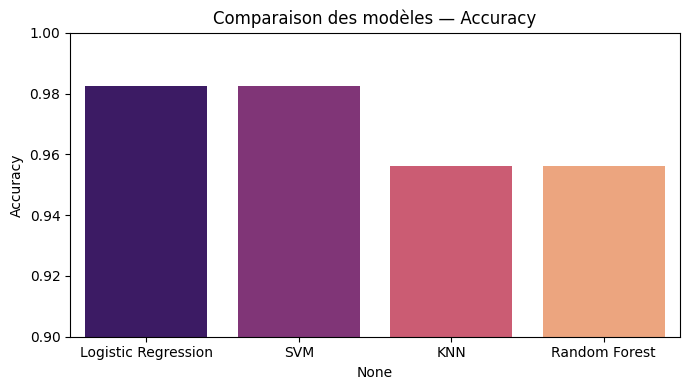

In [5]:
# ── COMPARAISON ─────────────────────────────────────────────

print("\n=== Tableau comparatif ===")
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False).round(4)
display(df_results)

best_model = df_results.idxmax()[0]
print(f"\n✅ Meilleur modèle : {best_model} ({df_results.loc[best_model, 'Accuracy']:.4f})")

# Barplot des accuracies
plt.figure(figsize=(7, 4))
sns.barplot(x=df_results.index, y='Accuracy', data=df_results, palette='magma')
plt.title("Comparaison des modèles — Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()